In [ ]:
import os
import numpy as np
import torch
import torchvision 
import matplotlib 
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import transforms 

Il est possible de mettre le tableau de classification des galaxies de manière locale. Néanmoins, étant donné la taille du jeu de données (les images des galaxies), il faut télécharger le fichier au lien suivant, et l'importer depuis son ordinateur : 


https://zenodo.org/records/3565489

* 1) Téléchargement des données sur l'ordinateur de l'utilisateur si elles ne sont pas téléchargées de manière locale : 



In [3]:
import os
from pathlib import Path
import sys

from types import SimpleNamespace

# Add parent directory to sys.path to import STL package modules
PARENT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(PARENT_DIR)
print("Parent directory added to sys.path:", ".../" + os.path.basename(PARENT_DIR))

# Path to test data
DATA_TEST_PATH = PARENT_DIR + "/data" + "/test"
print(
    "Dataset directory used:",
    ".../" + os.path.basename(PARENT_DIR) + DATA_TEST_PATH.split(os.path.basename(PARENT_DIR))[-1]
)

Parent directory added to sys.path: .../L3
Dataset directory used: .../L3/data/test


- Téléchargement local 


In [5]:
image_dir = r"C://Users//camil//Desktop//L3//Deep_learning_3//Projet_Deep_Learning_Galaxies//data_galaxies"
print(os.path.exists(image_dir))
print(os.listdir(image_dir)[:20])

True
['100.jpg', '1000.jpg', '10000.jpg', '100000.jpg', '100001.jpg', '100002.jpg', '100003.jpg', '100004.jpg', '100005.jpg', '100006.jpg', '100007.jpg', '100008.jpg', '10001.jpg', '100010.jpg', '100011.jpg', '100012.jpg', '100013.jpg', '100014.jpg', '100015.jpg', '100016.jpg']


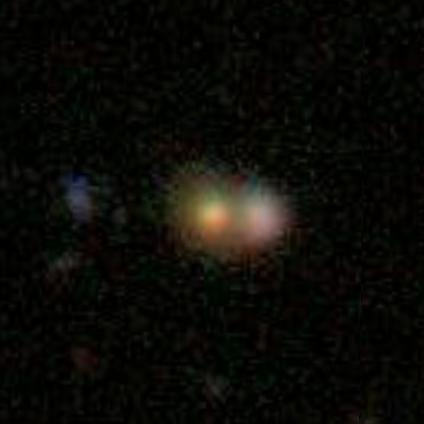

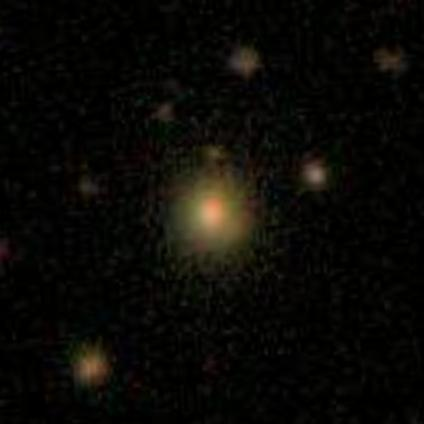

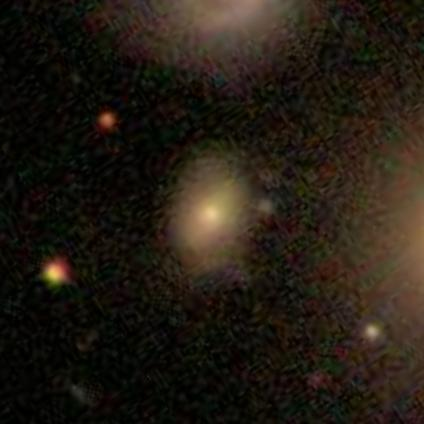

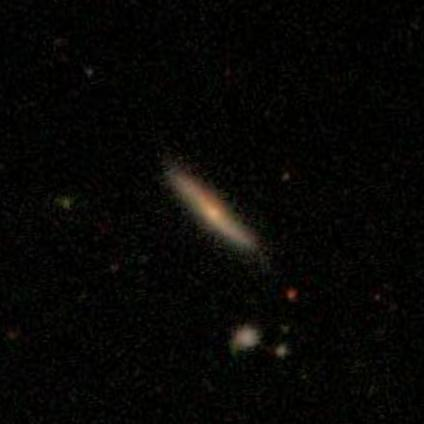

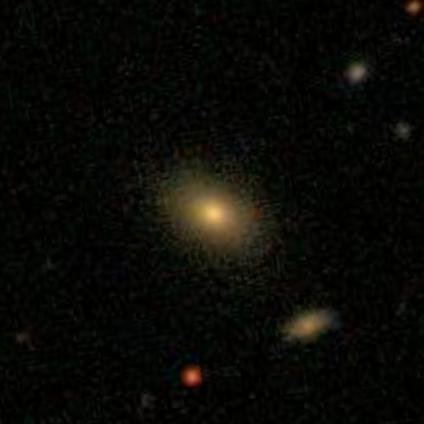

In [6]:
from PIL import Image

files = [f for f in os.listdir(image_dir) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
for fn in files[:5]:
    img = Image.open(os.path.join(image_dir, fn))
    display(img)

**Construction du dataset**

Grâce à la fonction ci-dessous, nous obtenons un dataset balancé de 15 000 images, chaque classe (elliptical, spiral, uncertain)
est représentée par 5 000 images.


In [ ]:

from __future__ import annotations

import argparse
import csv
import random
import tempfile
import time
import zipfile
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from urllib.error import HTTPError, URLError
from urllib.parse import urlencode
from urllib.request import Request, urlopen


CLASSES = ("spiral", "elliptical", "uncertain")
CLASS_COLUMNS = {
    "spiral": "SPIRAL",
    "elliptical": "ELLIPTICAL",
    "uncertain": "UNCERTAIN",
}


def hms_to_degrees(value: str) -> float:
    hours, minutes, seconds = value.strip().split(":")
    return 15.0 * (float(hours) + float(minutes) / 60.0 + float(seconds) / 3600.0)


def dms_to_degrees(value: str) -> float:
    value = value.strip()
    sign = -1.0 if value.startswith("-") else 1.0
    value = value.lstrip("+-")
    degrees, minutes, seconds = value.split(":")
    return sign * (float(degrees) + float(minutes) / 60.0 + float(seconds) / 3600.0)


def row_class(row: dict[str, str]) -> str | None:
    active = [label for label, column in CLASS_COLUMNS.items() if row[column] == "1"]
    if len(active) != 1:
        return None
    return active[0]


def read_balanced_rows(catalog_zip: Path, per_class: int, seed: int) -> list[dict[str, str]]:
    grouped: dict[str, list[dict[str, str]]] = {label: [] for label in CLASSES}

    with zipfile.ZipFile(catalog_zip) as archive:
        csv_name = archive.namelist()[0]
        with archive.open(csv_name) as csv_file:
            text_rows = (line.decode("utf-8") for line in csv_file)
            reader = csv.DictReader(text_rows)
            for row in reader:
                label = row_class(row)
                if label is not None:
                    grouped[label].append(row)

    rng = random.Random(seed)
    selected: list[dict[str, str]] = []
    for label in CLASSES:
        rows = grouped[label]
        if len(rows) < per_class:
            raise ValueError(
                f"Only found {len(rows)} rows for {label}; need {per_class}."
            )
        rng.shuffle(rows)
        for row in rows[:per_class]:
            row["CLASS"] = label
            row["RA_DEG"] = f"{hms_to_degrees(row['RA']):.10f}"
            row["DEC_DEG"] = f"{dms_to_degrees(row['DEC']):.10f}"
            selected.append(row)

    rng.shuffle(selected)
    return selected


def cutout_url(row: dict[str, str], release: str, scale: float, size: int) -> str:
    query = urlencode(
        {
            "ra": row["RA_DEG"],
            "dec": row["DEC_DEG"],
            "scale": scale,
            "width": size,
            "height": size,
            "opt": "",
        }
    )
    return f"https://skyserver.sdss.org/{release}/SkyServerWS/ImgCutout/getjpeg?{query}"


def image_path(output_dir: Path, row: dict[str, str]) -> Path:
    return output_dir / "images" / row["CLASS"] / f"{row['OBJID']}.jpg"


def write_manifest(rows: list[dict[str, str]], output_dir: Path, release: str, scale: float, size: int) -> Path:
    manifest_path = output_dir / "manifest.csv"
    manifest_path.parent.mkdir(parents=True, exist_ok=True)

    fieldnames = [
        "objid",
        "class",
        "ra",
        "dec",
        "ra_deg",
        "dec_deg",
        "nvote",
        "p_el_debiased",
        "p_cs_debiased",
        "image_path",
        "source_url",
    ]
    with manifest_path.open("w", newline="") as manifest_file:
        writer = csv.DictWriter(manifest_file, fieldnames=fieldnames)
        writer.writeheader()
        for row in rows:
            path = image_path(output_dir, row)
            writer.writerow(
                {
                    "objid": row["OBJID"],
                    "class": row["CLASS"],
                    "ra": row["RA"],
                    "dec": row["DEC"],
                    "ra_deg": row["RA_DEG"],
                    "dec_deg": row["DEC_DEG"],
                    "nvote": row["NVOTE"],
                    "p_el_debiased": row["P_EL_DEBIASED"],
                    "p_cs_debiased": row["P_CS_DEBIASED"],
                    "image_path": path.relative_to(output_dir),
                    "source_url": cutout_url(row, release, scale, size),
                }
            )

    return manifest_path


def download_one(
    row: dict[str, str],
    output_dir: Path,
    release: str,
    scale: float,
    size: int,
    timeout: int,
    retries: int,
    overwrite: bool,
) -> tuple[str, bool, str]:
    destination = image_path(output_dir, row)
    if destination.exists() and destination.stat().st_size > 0 and not overwrite:
        return row["OBJID"], True, "exists"

    destination.parent.mkdir(parents=True, exist_ok=True)
    url = cutout_url(row, release, scale, size)
    request = Request(url, headers={"User-Agent": "GalaxyZooDatasetBuilder/1.0"})

    for attempt in range(1, retries + 2):
        try:
            with urlopen(request, timeout=timeout) as response:
                content = response.read()
            if not content.startswith(b"\xff\xd8"):
                raise ValueError("response was not a JPEG")

            with tempfile.NamedTemporaryFile(
                "wb", delete=False, dir=destination.parent, suffix=".tmp"
            ) as tmp_file:
                tmp_file.write(content)
                tmp_path = Path(tmp_file.name)
            tmp_path.replace(destination)
            return row["OBJID"], True, "downloaded"
        except (HTTPError, URLError, TimeoutError, ValueError) as exc:
            if attempt > retries:
                return row["OBJID"], False, str(exc)
            time.sleep(0.5 * attempt)

    return row["OBJID"], False, "unknown failure"


def download_images(args: argparse.Namespace, rows: list[dict[str, str]]) -> None:
    done = 0
    failed: list[tuple[str, str]] = []
    total = len(rows)

    with ThreadPoolExecutor(max_workers=args.workers) as executor:
        futures = [
            executor.submit(
                download_one,
                row,
                args.output_dir,
                args.release,
                args.scale,
                args.size,
                args.timeout,
                args.retries,
                args.overwrite,
            )
            for row in rows
        ]
        for future in as_completed(futures):
            objid, ok, message = future.result()
            done += 1
            if not ok:
                failed.append((objid, message))
            if done % 100 == 0 or done == total:
                print(f"{done}/{total} images processed; failures: {len(failed)}")

    if failed:
        failure_path = args.output_dir / "download_failures.csv"
        with failure_path.open("w", newline="") as failure_file:
            writer = csv.writer(failure_file)
            writer.writerow(["objid", "error"])
            writer.writerows(failed)
        print(f"Recorded {len(failed)} failures in {failure_path}")


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Create a balanced Galaxy Zoo 1 SDSS image dataset."
    )
    parser.add_argument("--catalog-zip", type=Path, default=Path("GalaxyZoo1_DR_table2.csv.zip"))
    parser.add_argument("--output-dir", type=Path, default=Path("galaxy_zoo_balanced_15000"))
    parser.add_argument("--per-class", type=int, default=5000)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--release", default="dr16")
    parser.add_argument("--scale", type=float, default=0.396)
    parser.add_argument("--size", type=int, default=256)
    parser.add_argument("--workers", type=int, default=8)
    parser.add_argument("--timeout", type=int, default=30)
    parser.add_argument("--retries", type=int, default=2)
    parser.add_argument("--manifest-only", action="store_true")
    parser.add_argument("--overwrite", action="store_true")
    return parser.parse_args()


def main() -> None:
    args = parse_args()
    rows = read_balanced_rows(args.catalog_zip, args.per_class, args.seed)
    manifest_path = write_manifest(rows, args.output_dir, args.release, args.scale, args.size)

    print(f"Wrote manifest: {manifest_path}")
    print(f"Selected {len(rows)} rows: {args.per_class} per class")

    if args.manifest_only:
        return

    download_images(args, rows)


if __name__ == "__main__":
    main()

**Arbres de décision et Random Forest**

In [ ]:
batch_size = 64

# build transform
transform = transforms.Compose([
    transforms.ToTensor(),
    ])

